# Titanic Survival Analysis
## Exploratory Data Analysis (EDA) Using Python

# Import Libraries

In [23]:
# Import Required Libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Visualization Style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [26]:
# Display Settings
pd.set_option('display.max_columns', None)

# Load Dataset

In [3]:
# Load Dataset
df = pd.read_csv("Downloads/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

In [5]:
# Dataset Shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 891
Columns: 12


In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


# Data Quality Assessment

In [10]:
# Missing Values
missing = df.isnull().sum()
missing[missing > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [11]:
# Missing Value Percentage

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_percent.sort_values(
    ascending=False
)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

# Data Cleaning

In [12]:
# Fill Missing Age Values

df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

In [13]:
# Fill Missing Embarked Values

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

In [14]:
# Drop Cabin Column
df.drop(
    columns=['Cabin'],
    inplace=True
)

# Univariate Analysis
## Survival Distribution

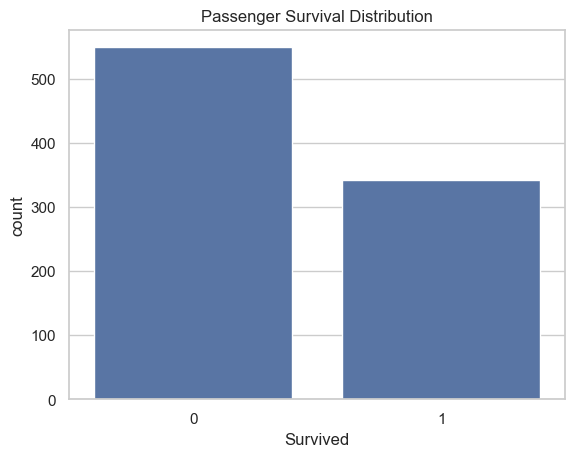

In [15]:
sns.countplot(
    x='Survived',
    data=df
)

plt.title(
    'Passenger Survival Distribution'
)

plt.show()

## Does Gender Affect Survival?

In [16]:
survival_by_gender = pd.crosstab(
    df['Sex'],
    df['Survived']
)

survival_by_gender

Survived,0,1
Sex,,
female,81,233
male,468,109


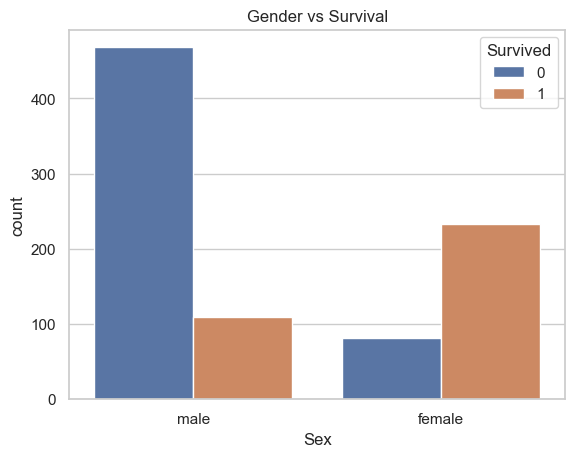

In [17]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title(
    'Gender vs Survival'
)

plt.show()

# Insight

### Female passengers had significantly higher survival rates compared to male passengers.

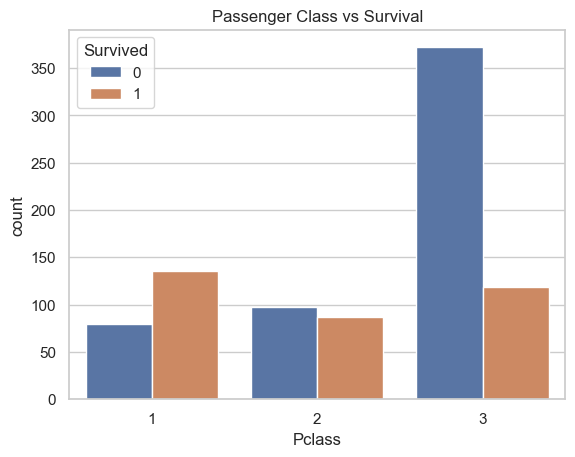

In [18]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title(
    'Passenger Class vs Survival'
)

plt.show()

## First-class passengers were more likely to survive than second and third-class passengers.

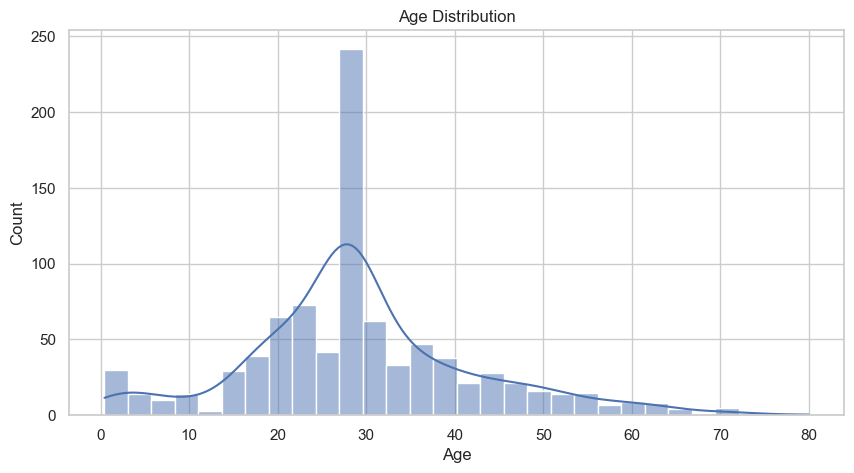

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title(
    'Age Distribution'
)

plt.show()

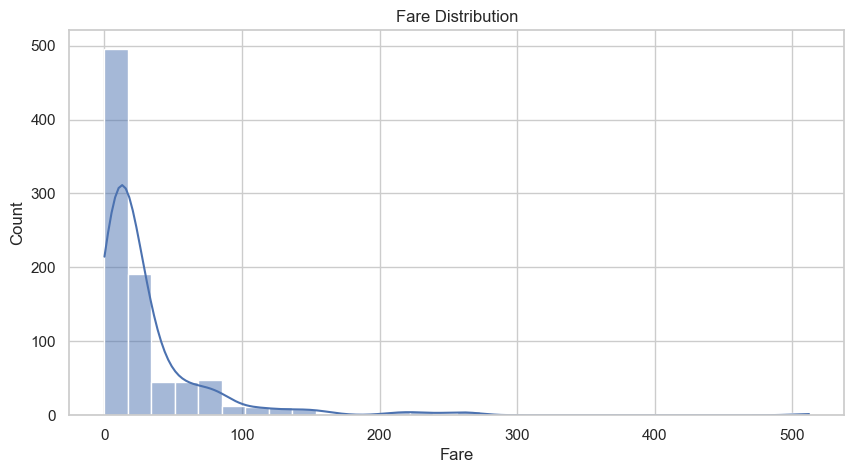

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Fare'],
    bins=30,
    kde=True
)

plt.title(
    'Fare Distribution'
)

plt.show()

## Correlation Analysis

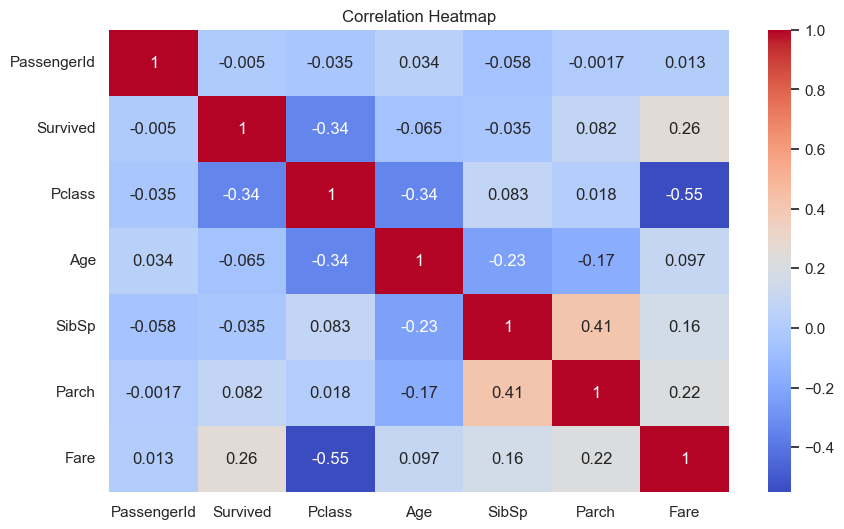

In [21]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

## Save Cleaned Dataset

In [22]:
df.to_csv(
    "cleaned_titanic.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

Cleaned dataset saved successfully.
